# Energy Conservation Check

The goal of this notebook is to validate that energy conservation holds over the duration of the simulation.

In [1]:
#First import the various libraries needed
import sys
sys.path.append('/storage/home/hcoda1/9/dmathews33/Spin-tracking/scripts')
import nedmSim
import numpy as np
import matplotlib.pyplot as plt

In [167]:
tf = 500.0
tout = 10.0
numParticles = 1000000
seed = 0

parameters = {}
parameters['particle'] = 'neutron' #choose particle type
parameters['dist'] = 'C' #velocity distribution method
parameters['T']='0.4' #set the temperature if using the distribution = 'M' option
parameters['gas_coll']='false' #are we doing phonon collisions? yes for helium-3 usually
parameters['diffuse']='1.0' #diffuse collisions? 0 = specular, 1 = diffuse, 0.5 is 50% diffuse, etc
parameters['gravity']='true' #gravity on or off?
parameters['B0'] = '3.0e-6, 0, 0' #magnetic field
parameters['numParticles'] = str(numParticles) #number of particles
parameters['numPerGPUBlock'] = '256' #number of particles per GPU block, does nothing on CPU
parameters['t0']='0.0' #start time of the simulation
parameters['tf']=str(tf) #stop time of the simulation
parameters['ioutInt']=str(tout) #output interval
parameters['a']= '0' #'19.1024180e-6' #driving field amplitude
parameters['w']='0' #'3000.0' #driving field frequency
parameters['h']='1e-5' #starting step size
parameters['keepStepSize'] = 'false' #do we remember the step size between function calls
parameters['fixedStepSize'] = 'false' #is the step size for spin integration fixed?
parameters['rtol'] = '1.0e-12' #relative precision desired for spin integration
parameters['atol'] = '1.0e-12' #absolute precision desired for spin integration
parameters['hmax'] = '1.0' #largest step size allowed for spin integration
parameters['hmin'] = '1.0e-9' #smallest step size allowed for spin integration
parameters['seed'] = str(seed) #random number seed for the first particle
parameters['integratorType'] = '-1' #the spin integration method
parameters['V'] = '5.0'

filenameDiffuse = 'energytestDiffuse.txt'
nedmSim.writeParameterFile(filenameDiffuse, parameters)

parameters['diffuse'] = '0'
filenameSpecular = 'energytestSpecular.txt'
nedmSim.writeParameterFile(filenameSpecular, parameters)

outputNameDiffuse = '/storage/home/hcoda1/9/dmathews33/scratch/energyConservationTestDiffuse.out'
outputNameSpecular = '/storage/home/hcoda1/9/dmathews33/scratch/energyConservationTestSpecular.out'

In [168]:
!~/Spin-tracking/bit64main {filenameDiffuse} {outputNameDiffuse}
!~/Spin-tracking/bit64main {filenameSpecular} {outputNameSpecular}

648
iter 0, duration 10, 361
iter 1, duration 20, 284
iter 2, duration 30, 285
iter 3, duration 40, 290
iter 4, duration 50, 286
iter 5, duration 60, 279
iter 6, duration 70, 277
iter 7, duration 80, 276
iter 8, duration 90, 274
iter 9, duration 100, 277
iter 10, duration 110, 280
iter 11, duration 120, 274
iter 12, duration 130, 282
iter 13, duration 140, 280
iter 14, duration 150, 279
iter 15, duration 160, 280
iter 16, duration 170, 273
iter 17, duration 180, 276
iter 18, duration 190, 289
iter 19, duration 200, 279
iter 20, duration 210, 283
iter 21, duration 220, 274
iter 22, duration 230, 275
iter 23, duration 240, 281
iter 24, duration 250, 278
iter 25, duration 260, 284
iter 26, duration 270, 277
iter 27, duration 280, 275
iter 28, duration 290, 280
iter 29, duration 300, 278
iter 30, duration 310, 278
iter 31, duration 320, 276
iter 32, duration 330, 281
iter 33, duration 340, 280
iter 34, duration 350, 273
iter 35, duration 360, 276
iter 36, duration 370, 282
iter 37, duratio

In [169]:
diffuseResults = nedmSim.readInOutputFile(outputNameDiffuse, pad=3)
specularResults= nedmSim.readInOutputFile(outputNameSpecular, pad=3)

In [170]:
errorsDiffuse = diffuseResults[1]['errorState']
errorsSpecular = specularResults[1]['errorState']

In [171]:
np.unique(errorsDiffuse[-1,:], return_counts=True)

(array([0], dtype=int32), array([1000000]))

In [172]:
np.unique(errorsSpecular[-1,:], return_counts=True)

(array([0], dtype=int32), array([1000000]))

In [173]:
def calcTotalEnergy(params, dset, gravity=True):
    PE = 0
    if gravity:
        PE = (dset['x'][:,:,1]+params['L'][1]/2.0)*9.81
    v = np.sqrt(dset['v'][:,:,0]**2.0 + dset['v'][:,:,1]**2.0 + dset['v'][:,:,2]**2.0)
    KE = 0.5 * v**2.0
    TE = PE + KE
    return TE * params['m'] * 6.242e18*1e9 #convert to neV

In [174]:
energySpec = calcTotalEnergy(specularResults[0], specularResults[1], gravity=True)
energyDiff = calcTotalEnergy(diffuseResults[0], diffuseResults[1], gravity=True)

In [175]:
np.where(np.isnan(energySpec[-1,:]))[0].shape

(0,)

In [176]:
np.where(np.isnan(energyDiff[-1,:]))[0].shape

(0,)

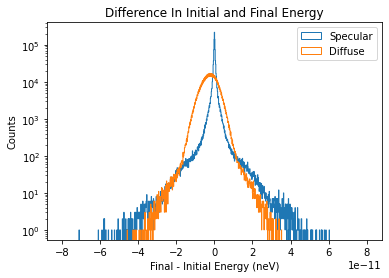

In [177]:
bins = np.linspace(-8e-11, 8e-11, 1000)
plt.hist(energySpec[0,:] - energySpec[-1,:], bins=bins, label='Specular', histtype='step')
plt.hist(energyDiff[0,:] - energyDiff[-1,:], bins=bins, label='Diffuse', histtype='step')
plt.xlabel('Final - Initial Energy (neV)')
plt.ylabel('Counts')
plt.title('Difference In Initial and Final Energy')
plt.yscale('log')
plt.legend()
plt.show()